In [1]:
# import all the necessary libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore')

In [2]:
df = pd.read_csv('House_Rent_Dataset.csv')
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [3]:
df.columns

Index(['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type',
       'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Bathroom', 'Point of Contact'],
      dtype='object')

In [4]:
df.shape

(4746, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


In [6]:
# df stat
df.describe()

,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


In [7]:
# missing values
df.isnull().sum()

Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.head(2)

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner


In [10]:
df = df.drop(['Posted On', 'Floor', 'Area Locality'], axis=1)
# df.drop(['Posted On', 'Floor', 'Area Locality'], axis=1, inplace=True)
df.head()

,BHK,Rent,Size,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2,10000,1100,Super Area,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2,20000,800,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2,17000,1000,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2,10000,800,Super Area,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2,7500,850,Carpet Area,Kolkata,Unfurnished,Bachelors,1,Contact Owner


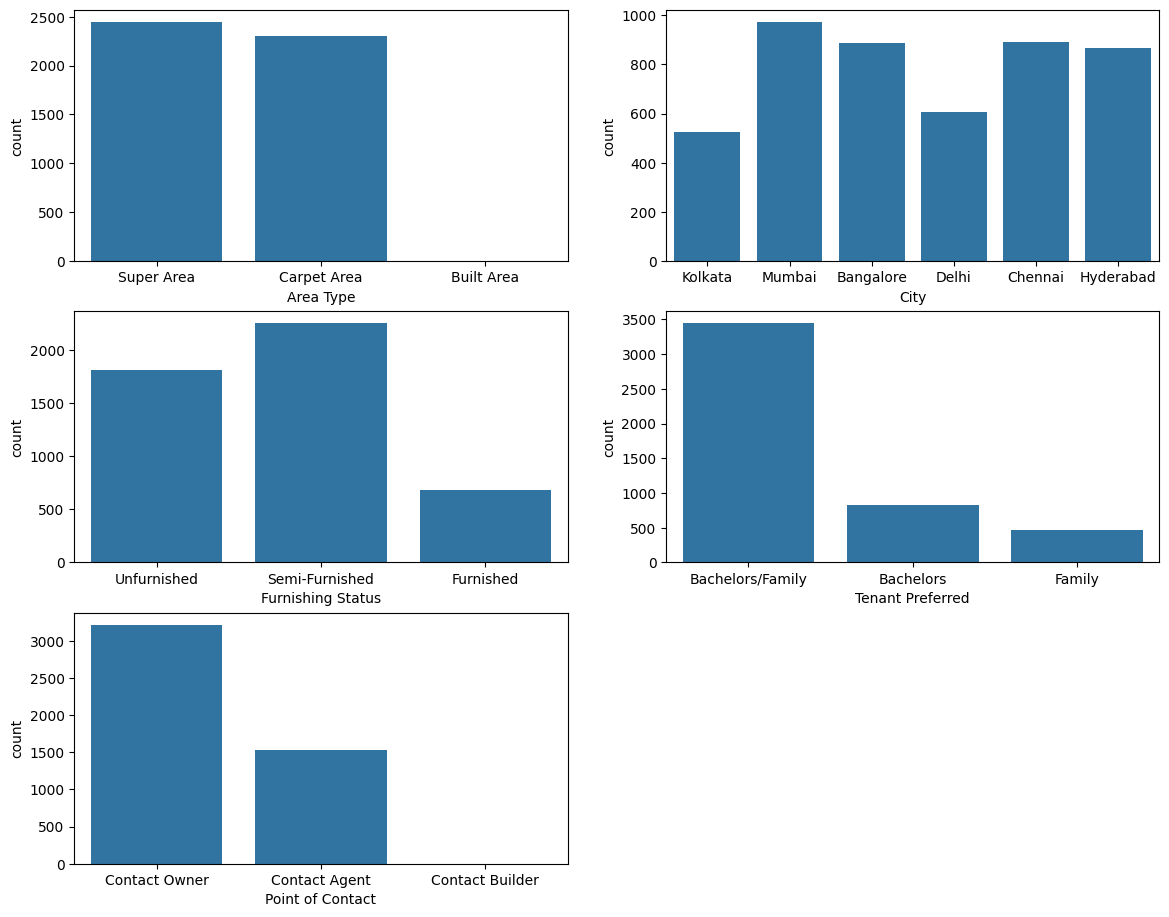

In [11]:
# visualization
plt.figure(figsize=(14, 15))
for i, col in enumerate (['Area Type', 'City', 'Furnishing Status', 
                         'Tenant Preferred', 'Point of Contact']):
    plt.subplot(4, 2, i+1)
    sns.countplot(data=df, x=col)

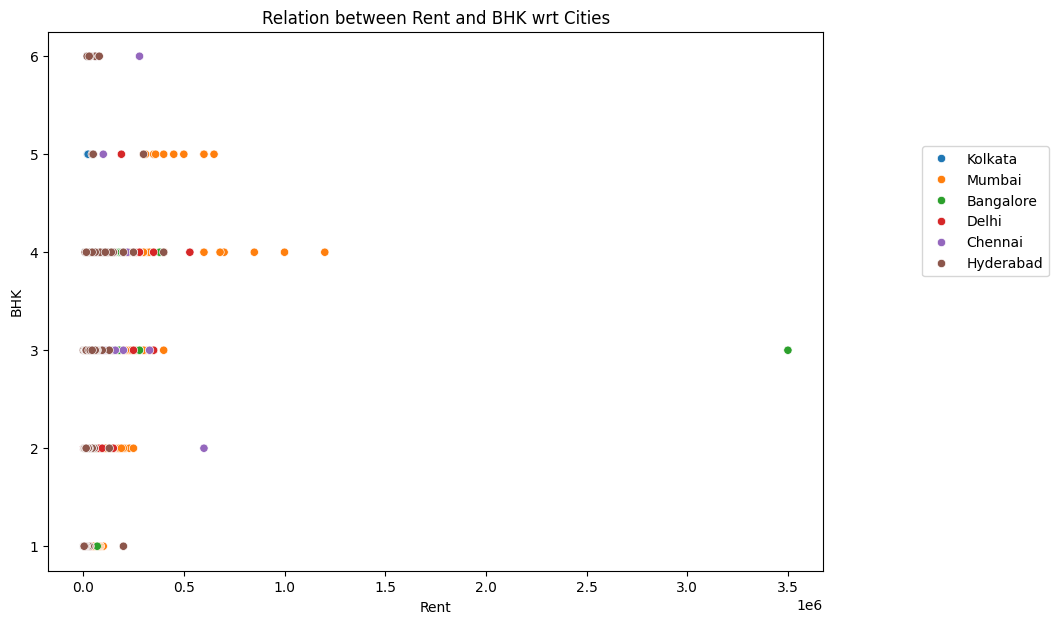

In [13]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Rent', y='BHK', data=df, hue='City')
plt.legend(bbox_to_anchor=(1.3, 0.8))
plt.title('Relation between Rent and BHK wrt Cities')
plt.show()

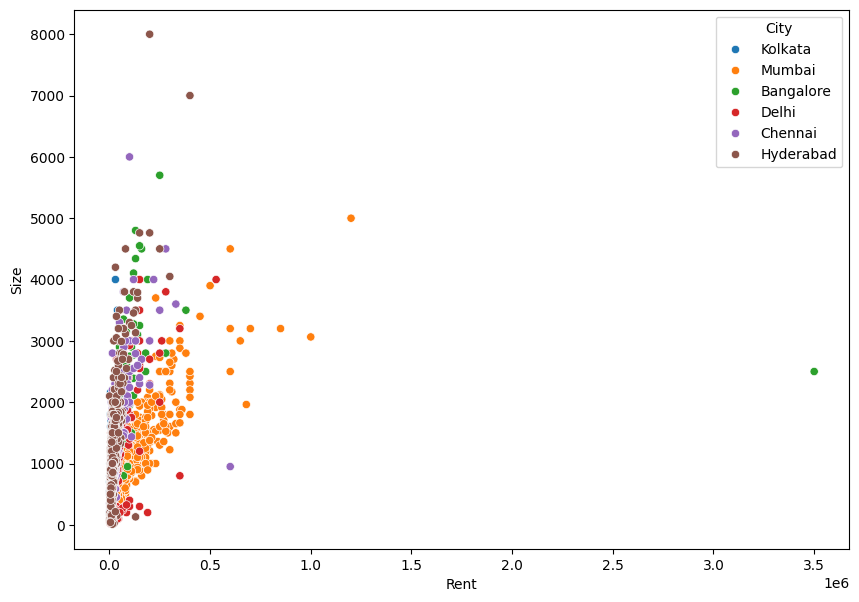

In [14]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Rent', y='Size', hue='City', data=df)
plt.show()

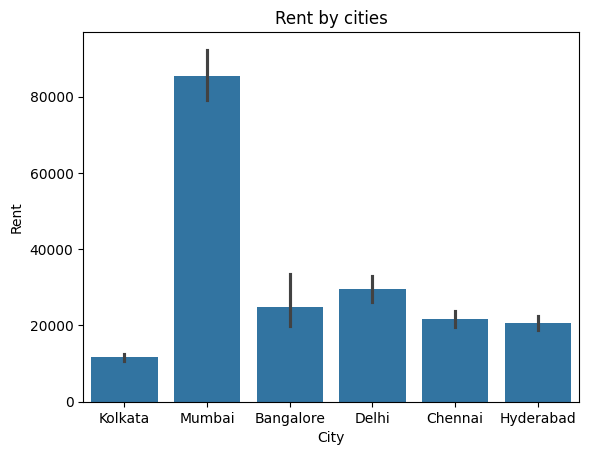

In [15]:
sns.barplot(data=df, x='City', y='Rent')
plt.title('Rent by cities')
plt.show()

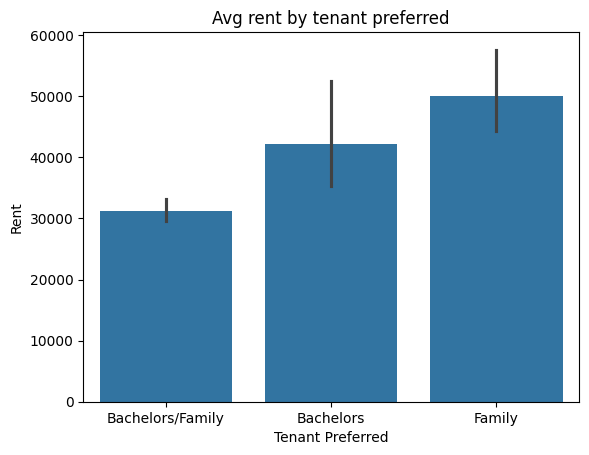

In [16]:
sns.barplot(data=df, x='Tenant Preferred', y='Rent')
plt.title('Avg rent by tenant preferred')
plt.show()

In [17]:
pip install category-encoders


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip3.13 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## data preprocessing and splitting

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
import sklearn.metrics as metrics
import xgboost as xgb
import category_encoders as ce
from sklearn.preprocessing import MinMaxScaler

In [19]:
def regression_results(y_true, y_pred):
    # regression metrics
    explained_variance = metrics.explained_variance_score(y_true, y_pred)
    mean_absolute_error = metrics.mean_absolute_error(y_true, y_pred)
    mean_squared_error = metrics.mean_squared_error(y_true, y_pred)
    r2 = metrics.r2_score(y_true, y_pred)

    print('Explained Variance: ', round(explained_variance, 4))
    print('Mean Absolute Error: ', round(mean_absolute_error, 4))
    print('Mean Squared Error: ', round(mean_squared_error, 4))
    print('R Squared Score: ', round(r2, 4))

In [20]:
categorical_cols = df.select_dtypes(include='object').columns
categorical_cols

Index(['Area Type', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Point of Contact'],
      dtype='object')

In [21]:
for col in categorical_cols:
    print(f'{col}:{df[col].nunique()}')

Area Type:3
City:6
Furnishing Status:3
Tenant Preferred:3
Point of Contact:3


In [22]:
x = df.drop(columns='Rent')
y = df['Rent']

In [26]:
encoder = ce.LeaveOneOutEncoder(return_df=True)
x = encoder.fit_transform(x, y)

In [27]:
x.head()

,BHK,Size,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2,1100,18676.943967,11648.319312,22468.505513,31216.953238,2,16706.291757
1,2,800,18672.853988,11629.198853,38727.130222,31214.048795,1,16703.181337
2,2,1000,18674.080982,11634.934990,38728.463556,31214.920128,1,16704.114463
3,2,800,18676.943967,11648.319312,22468.505513,31216.953238,1,16706.291757
4,2,850,52405.438398,11653.099426,22469.883682,42185.583836,1,16707.069362


In [28]:
scaler = MinMaxScaler()
x = scaler.fit_transform(x)
x

array([[0.2       , 0.13642053, 0.27316184, ..., 0.01795978, 0.11111111,
        0.00321938],
       [0.2       , 0.09887359, 0.27307371, ..., 0.01780886, 0.        ,
        0.00316481],
       [0.2       , 0.12390488, 0.27310014, ..., 0.01785413, 0.        ,
        0.00318118],
       ...,
       [0.4       , 0.21777222, 0.99968293, ..., 0.01758247, 0.22222222,
        0.99965557],
       [0.4       , 0.1864831 , 0.99958912, ..., 0.99558704, 0.11111111,
        0.99954076],
       [0.2       , 0.12390488, 0.99987054, ..., 0.58744851, 0.11111111,
        0.00319209]], shape=(4746, 8))

In [31]:
x_df = pd.DataFrame(x)
x_df.head()

,0,1,2,3,4,5,6,7
0,0.2,0.136421,0.273162,0.004388,0.009553,0.017960,0.111111,0.003219
1,0.2,0.098874,0.273074,0.004130,0.487075,0.017809,0.000000,0.003165
2,0.2,0.123905,0.273100,0.004207,0.487114,0.017854,0.000000,0.003181
3,0.2,0.098874,0.273162,0.004388,0.009553,0.017960,0.000000,0.003219
4,0.2,0.105131,0.999941,0.004452,0.009593,0.587919,0.000000,0.003233


In [32]:
x_train, x_test, y_trian, y_test = train_test_split(
    x, y, train_size=0.8, random_state=42
)

In [33]:
x_train.shape, x_test.shape

((3796, 8), (950, 8))

## Training the models and evaluating them

In [34]:
rfr = RandomForestRegressor(n_estimators=7)
dtr = DecisionTreeRegressor()
lr = LinearRegression()
xgb = xgb.XGBRegressor(objective='reg:squarederror')
models = [rfr,dtr,lr,xgb]

In [36]:
for model in models:
    print(f'Fitting the model:{model}')
    model.fit(x_train, y_trian)

Fitting the model:RandomForestRegressor(n_estimators=7)
Fitting the model:DecisionTreeRegressor()
Fitting the model:LinearRegression()
Fitting the model:XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)


In [37]:
for model in models:
    print(f'score of {model} for training data: {model.score(x_train, 
                                                             y_trian)}')

score of RandomForestRegressor(n_estimators=7) for training data: 0.82463346515843
score of DecisionTreeRegressor() for training data: 1.0
score of LinearRegression() for training data: 0.2777139824412954
score of XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...) for training data: 0.999516487121582

In [38]:
for model in models[:]:
    y_predicted = model.predict(x_test)

    print(f'Report:{model}')
    print(f'{regression_results(y_test, y_predicted)}')

Report:RandomForestRegressor(n_estimators=7)
Explained Variance:  0.9137
Mean Absolute Error:  1488.0792
Mean Squared Error:  344043921.9509
R Squared Score:  0.9137
None
Report:DecisionTreeRegressor()
Explained Variance:  0.9354
Mean Absolute Error:  1169.4095
Mean Squared Error:  257417632.6221
R Squared Score:  0.9354
None
Report:LinearRegression()
Explained Variance:  0.5155
Mean Absolute Error:  22537.8643
Mean Squared Error:  1931480573.9932
R Squared Score:  0.5154
None
Report:XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None,

# Wine Quality Classification 

<h2> Understand about Dataset</h2>

Understanding the different features of wine, we see that there are a total of 12 columns including the final quality parameter. Let us try to find out what these columns mean and how do they contribute in determing the quality of the red wine!

* **Fixed Acidity:** are non-volatile acids that do not evaporate readily

* **Volatile Acidity:** are high acetic acid in wine which leads to an unpleasant vinegar taste

* **Citric Acid:** acts as a preservative to increase acidity. When in small quantities, adds freshness and flavor to wines

* **Residual Sugar:** is the amount of sugar remaining after fermentation stops. The key is to have a perfect balance between sweetness and sourness. It is important to note that wines > 45g/ltrs are sweet

* **Chlorides:** the amount of salt in the wine

* **Free Sulfur Dioxide:** it prevents microbial growth and the oxidation of wine

* **Total Sulfur Dioxide:** is the amount of free + bound forms of SO2

* **Density:** sweeter wines have a higher density

* **pH:** describes the level of acidity on a scale of 0–14. Most wines are always between 3–4 on the pH scale

* **Alcohol:** available in small quantities in wines makes the drinkers sociable

* **Sulphates:** a wine additive that contributes to SO2 levels and acts as an antimicrobial and antioxidant

* **Quality:** which is the output variable/predictor


Now we have a basic knowledge of various factors that influence the quality of good wine, Shall we drink to that? 🥂

## Now let's start with EDA first and then we go with Model prediction.

In [2]:
wdf = pd.read_csv('Lab 22 winequality-red.csv')
wdf.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
wdf.quality.nunique()

6

In [4]:
wdf.sample(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
949,8.9,0.12,0.45,1.8,0.075,10.0,21.0,0.99552,3.41,0.76,11.9,7
579,10.6,0.31,0.49,2.2,0.063,18.0,40.0,0.99760,3.14,0.51,9.8,6
1124,6.5,0.58,0.00,2.2,0.096,3.0,13.0,0.99557,3.62,0.62,11.5,4
1484,6.8,0.91,0.06,2.0,0.060,4.0,11.0,0.99592,3.53,0.64,10.9,4
643,9.5,0.59,0.44,2.3,0.071,21.0,68.0,0.99920,3.46,0.63,9.5,5


In [5]:
wdf.shape

(1599, 12)

In [7]:
wdf.info(0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [8]:
wdf.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [9]:
# missing values
wdf.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64


<Axes: xlabel='quality', ylabel='count'>

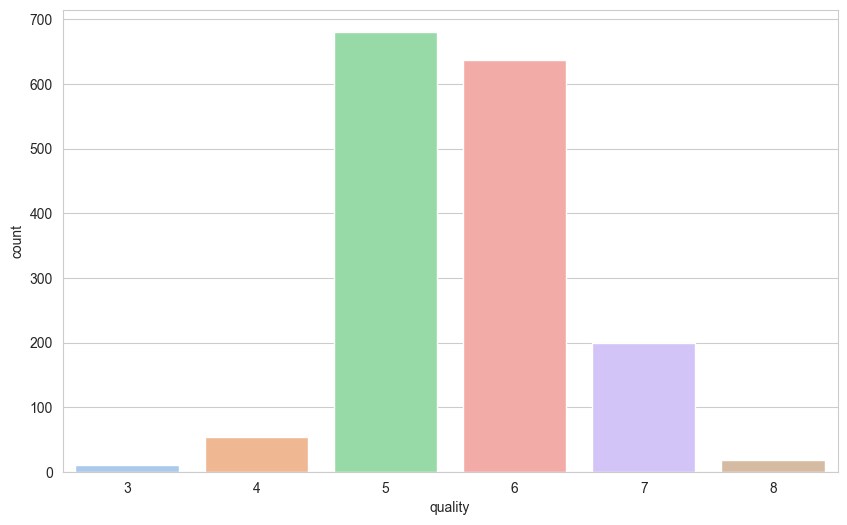

In [10]:
# visualization
sns.set_style(style='whitegrid')
print(wdf['quality'].value_counts())
fig = plt.figure(figsize=(10, 6))
sns.countplot(x='quality', data=wdf, palette='pastel')

<Axes: >

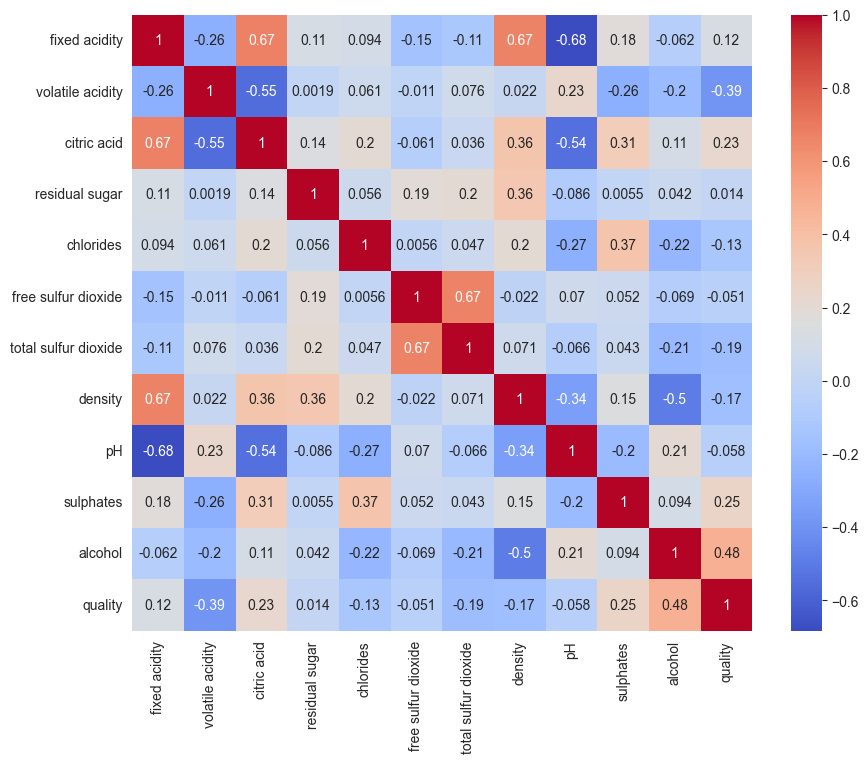

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(wdf.corr(), annot=True, cmap='coolwarm') # cmap='PuBuGn'

In [12]:
wdf.corr()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


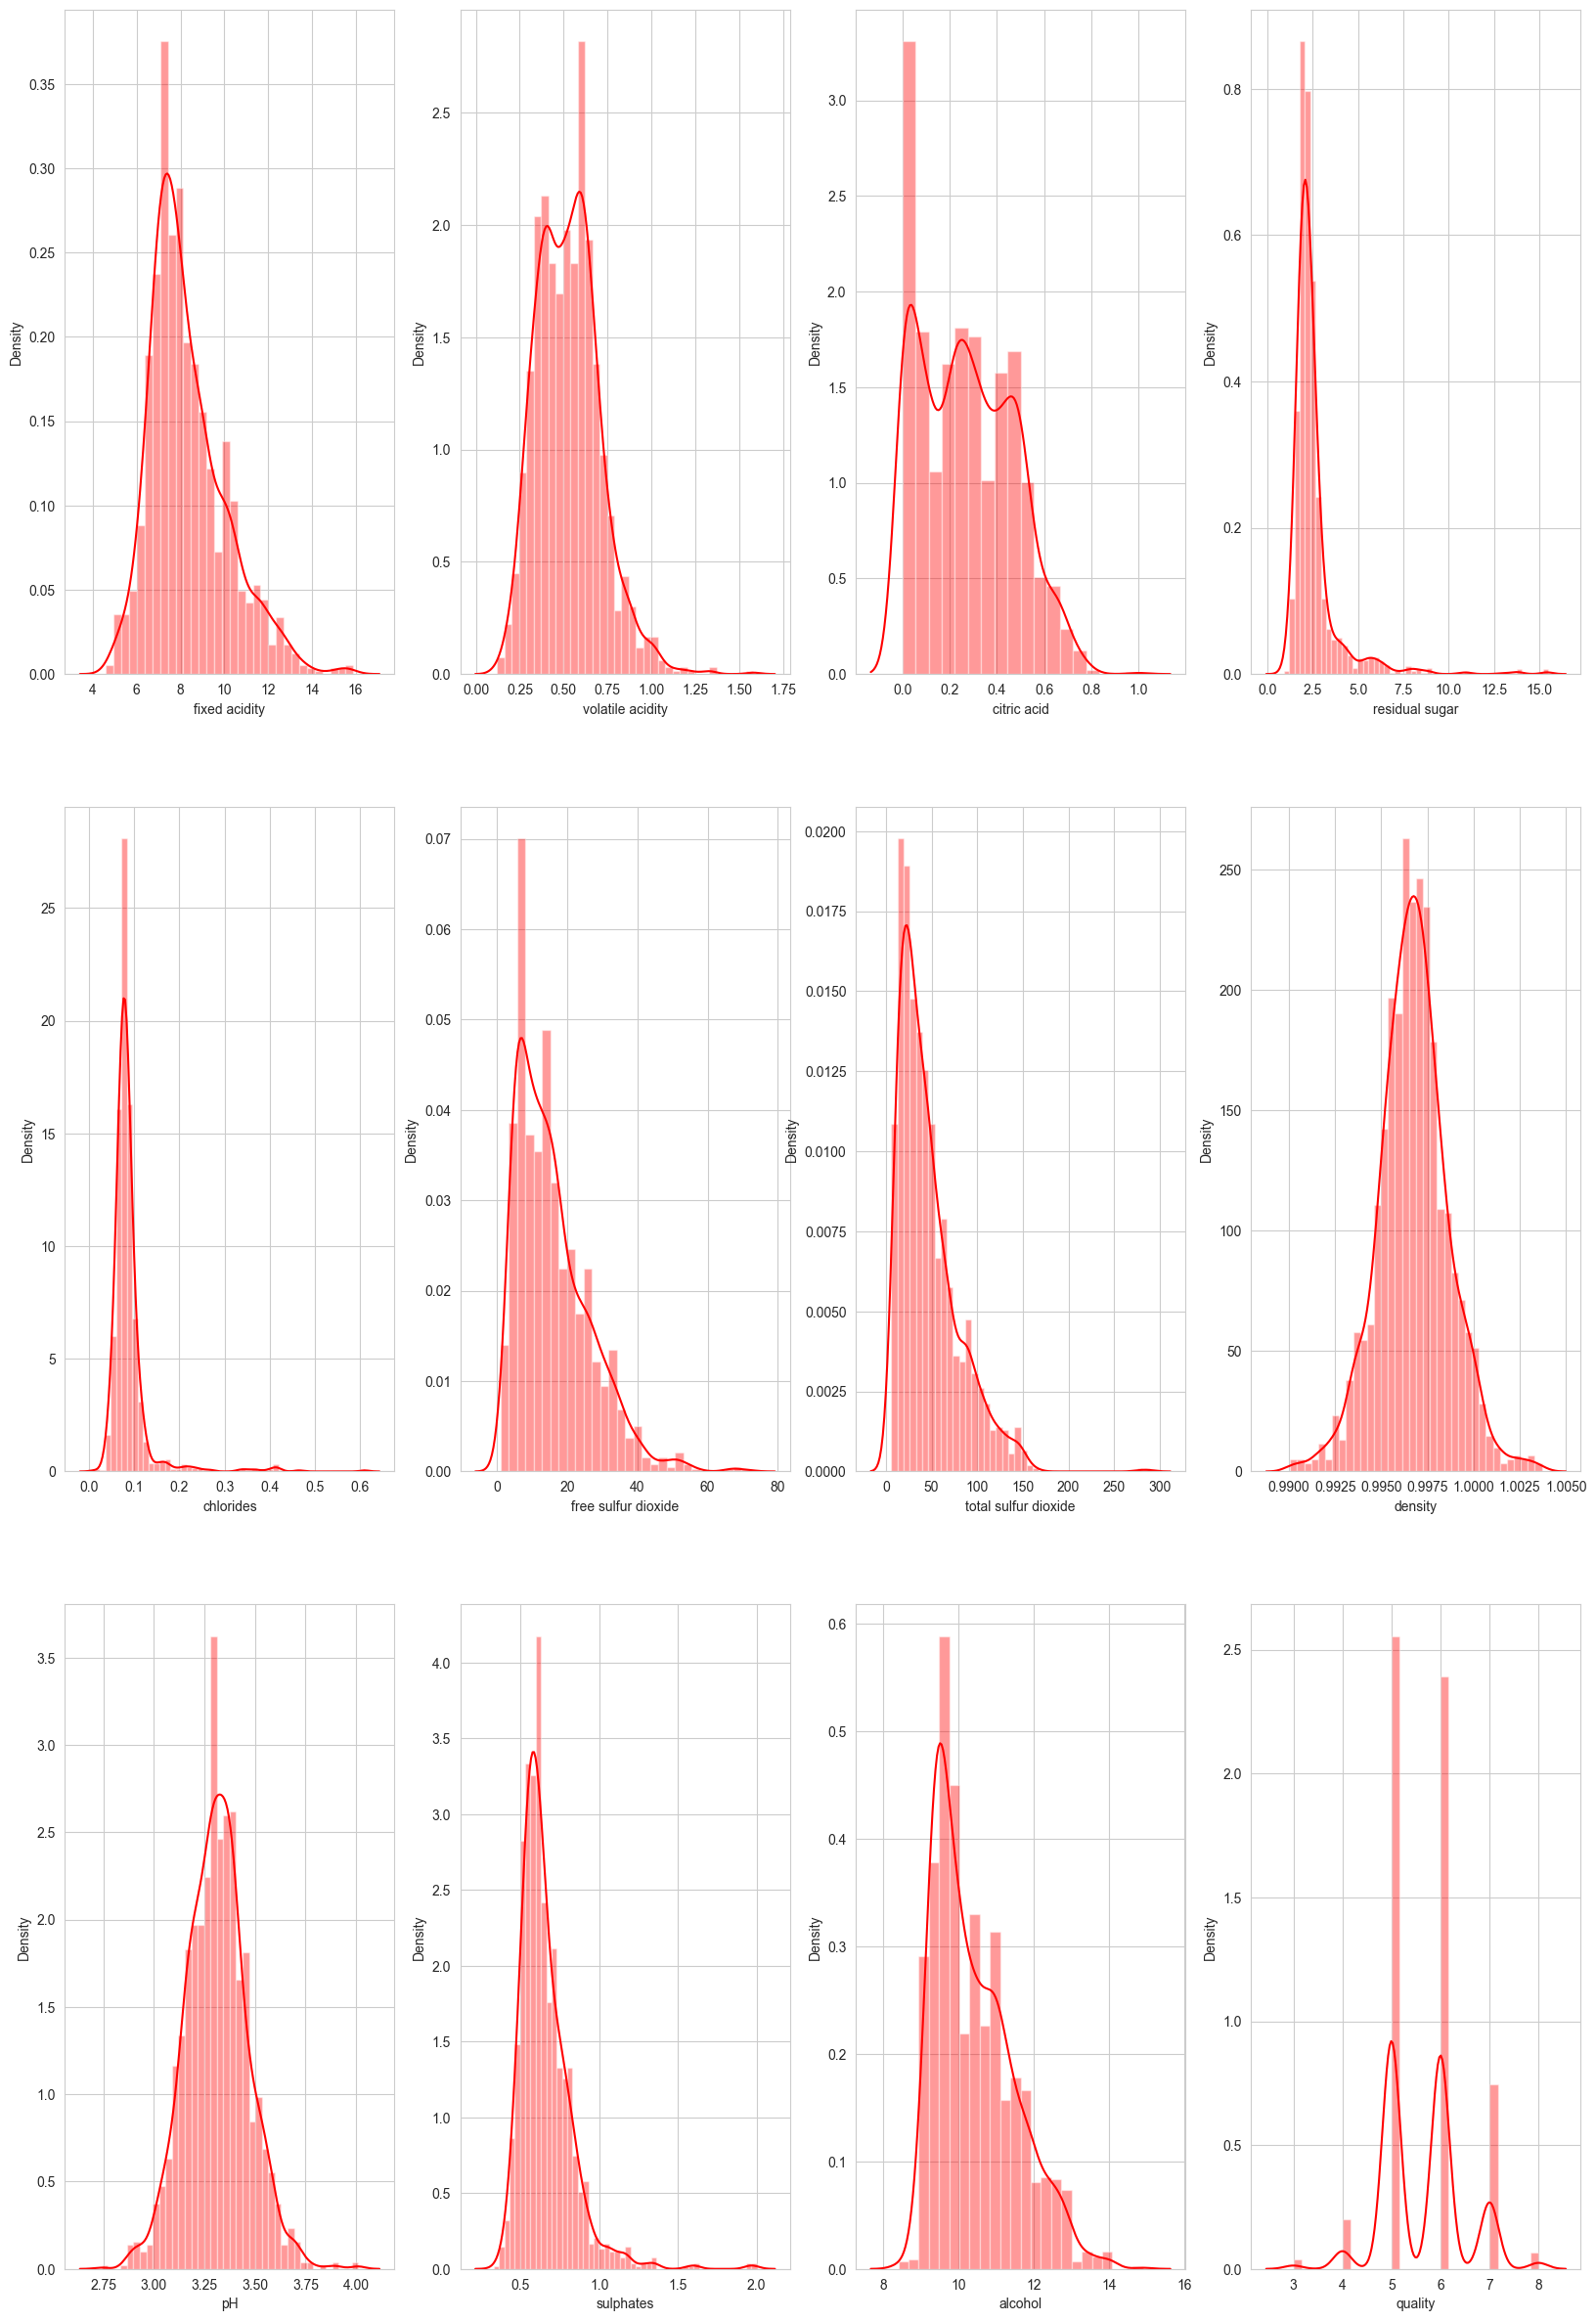

In [13]:
color = sns.color_palette('pastel')

fig, ax1 = plt.subplots(3, 4, figsize=(20, 30))
k = 0
columns = list(wdf.columns)
for i in range(3):
    for j in range(4):
        sns.distplot(wdf[columns[k]], ax = ax1[i][j], color='red')
        k += 1
plt.show()

In [14]:
def log_transform(col):
    return np.log(col)

In [15]:
wdf['residual sugar'] = wdf[['residual sugar']].apply(log_transform, 
                                                      axis = 1)
wdf['chlorides'] = wdf[['chlorides']].apply(log_transform, 
                                                      axis = 1)
wdf['free sulfur dioxide'] = wdf[['free sulfur dioxide']].apply(log_transform, 
                                                      axis = 1)
wdf['total sulfur dioxide'] = wdf[['total sulfur dioxide']].apply(log_transform, 
                                                      axis = 1)
wdf['sulphates'] = wdf[['sulphates']].apply(log_transform, 
                                                      axis = 1)


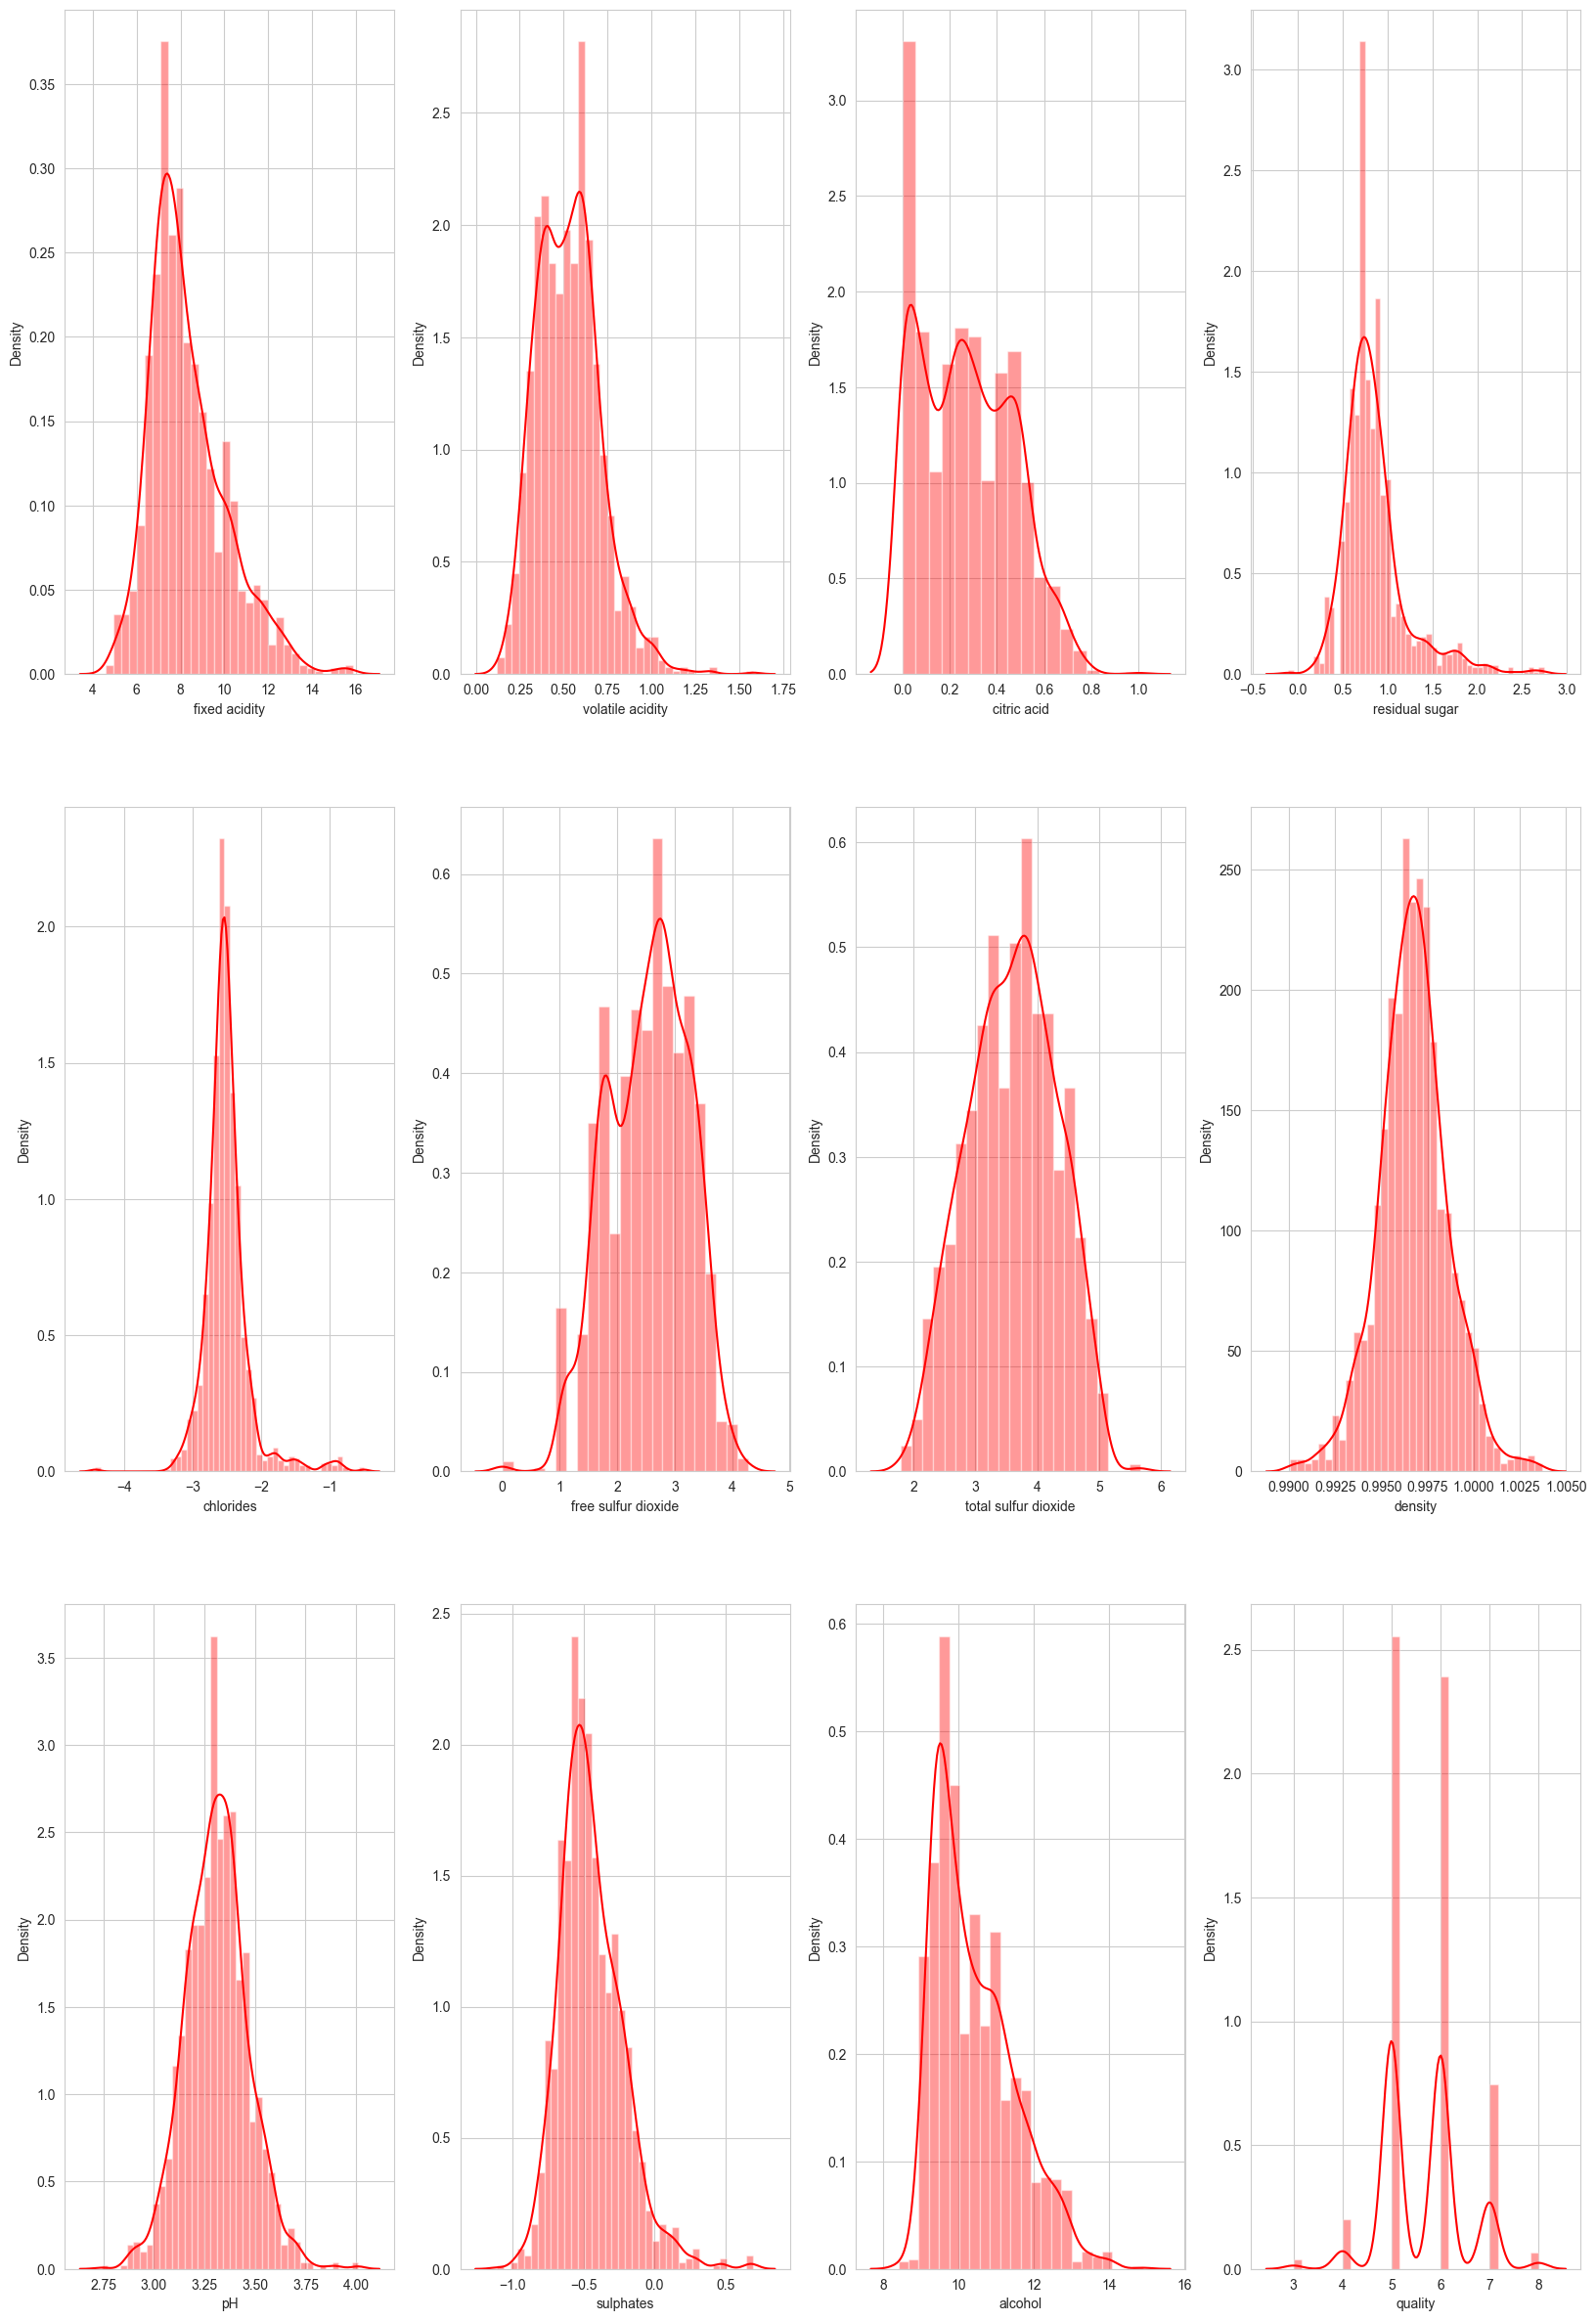

In [16]:
color = sns.color_palette('pastel')

fig, ax1 = plt.subplots(3, 4, figsize=(20, 30))
k = 0
columns = list(wdf.columns)
for i in range(3):
    for j in range(4):
        sns.distplot(wdf[columns[k]], ax = ax1[i][j], color='red')
        k += 1
plt.show()

In [17]:
wdf.corr()['quality'].sort_values(ascending=False)

quality                 1.000000
alcohol                 0.476166
sulphates               0.308642
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.023533
free sulfur dioxide    -0.050087
pH                     -0.057731
total sulfur dioxide   -0.170143
density                -0.174919
chlorides              -0.176140
volatile acidity       -0.390558
Name: quality, dtype: float64

In [18]:
# split the data
x = wdf.drop(columns=['quality'])
y = wdf['quality']

In [20]:
x

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.700,0.00,0.641854,-2.577022,2.397895,3.526361,0.99780,3.51,-0.579818,9.4
1,7.8,0.880,0.00,0.955511,-2.322788,3.218876,4.204693,0.99680,3.20,-0.385662,9.8
2,7.8,0.760,0.04,0.832909,-2.385967,2.708050,3.988984,0.99700,3.26,-0.430783,9.8
3,11.2,0.280,0.56,0.641854,-2.590267,2.833213,4.094345,0.99800,3.16,-0.544727,9.8
4,7.4,0.700,0.00,0.641854,-2.577022,2.397895,3.526361,0.99780,3.51,-0.579818,9.4
...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,0.693147,-2.407946,3.465736,3.784190,0.99490,3.45,-0.544727,10.5
1595,5.9,0.550,0.10,0.788457,-2.780621,3.663562,3.931826,0.99512,3.52,-0.274437,11.2
1596,6.3,0.510,0.13,0.832909,-2.577022,3.367296,3.688879,0.99574,3.42,-0.287682,11.0
1597,5.9,0.645,0.12,0.693147,-2.590267,3.465736,3.784190,0.99547,3.57,-0.342490,10.2


In [21]:
pip install imblearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [imblearn]

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip3.13 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [23]:
from imblearn.over_sampling import SMOTE
oversample = SMOTE(k_neighbors=4)
x, y = oversample.fit_resample(x.fillna(0), y)

In [24]:
y.value_counts()

quality
5    681
6    681
7    681
4    681
8    681
3    681
Name: count, dtype: int64

In [25]:
# classify function
from sklearn.model_selection import cross_val_score, train_test_split

def classify(model, x, y):
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.2, random_state=42
    )
    model.fit(x_train, y_train)
    return model.score(x_test, y_test) * 100

In [26]:
# apply logistic regression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
lr = classify(model, x, y)
lr

49.511002444987774

In [27]:
# apply support vector machine
from sklearn.svm import SVC
model = SVC(kernel='rbf', random_state=1)
svm = classify(model, x, y)
svm

51.34474327628362

In [28]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
dtc = classify(model,x,y)
dtc

78.85085574572128

In [29]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
rfc = classify(model, x, y)
rfc

85.57457212713936

In [30]:
accuracy = [lr, svm, dtc, rfc]
models = ['Logistic Regression', 'Support Vector Machine',
          'DecisionTreeClassifier', 'RandomForestClassifier']

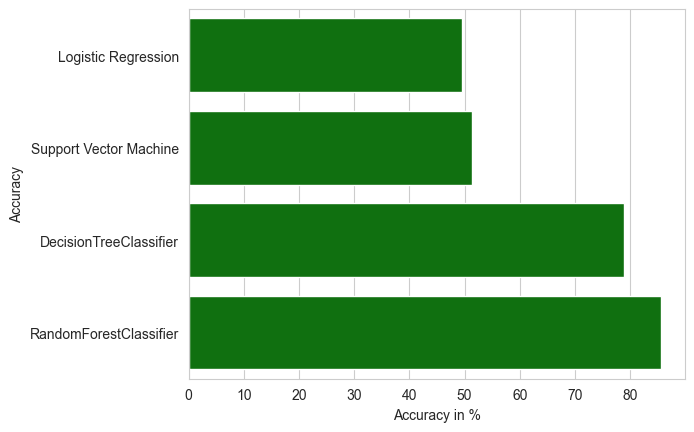

In [31]:
sns.barplot(x=accuracy, y=models, color='g')
plt.xlabel('Accuracy in %')
plt.ylabel('Accuracy')
plt.show()

In [33]:
# to save the model
import pickle
filename = 'RFCWDF.sav'
pickle.dump(rfc, open(filename, 'wb'))